In [39]:
# Cell 1 — Title & Overview
# ============================================================
# 03_ml_models.ipynb
# Olist Supply Chain Risk Intelligence
# ============================================================
# This notebook:
# 1. Pulls pre-delivery features from BigQuery (no leakage)
# 2. Builds seller and route historical stats
# 3. Trains XGBoost regression (delay days prediction)
# 4. Trains XGBoost classifier (late/on-time prediction)
# 5. Saves feature importance plot and predictions to BigQuery
# Prerequisites: 01_data_ingestion.ipynb must be run first
# ============================================================

In [40]:
# Cell 2 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_gbq
from google.oauth2 import service_account
from google.cloud import bigquery
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, roc_auc_score, classification_report
)
from xgboost import XGBRegressor, XGBClassifier

print("Libraries loaded ✅")

Libraries loaded ✅


In [41]:
# Cell 3 — Configuration
KEY_PATH   = "bq_key.json"   # update path if different

PROJECT_ID = "supply-chain-analytics-500607"
DATASET_ID = "olist"
TABLE_ID   = "orders_master"
TABLE      = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"

credentials = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

os.makedirs("../data", exist_ok=True)

def run_query(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

def save_to_bq(df: pd.DataFrame, table_name: str) -> None:
    pandas_gbq.to_gbq(
        df,
        destination_table=f"{DATASET_ID}.{table_name}",
        project_id=PROJECT_ID,
        credentials=credentials,
        if_exists="replace",
        progress_bar=False,
    )
    print(f"  ✅ BigQuery: {DATASET_ID}.{table_name}")

print(f"Connected to: {PROJECT_ID}.{DATASET_ID} ✅")

Connected to: supply-chain-analytics-500607.olist ✅


In [42]:
# Cell 4 — Load pre-delivery features from BigQuery
# NOTE: No shipping_duration_days — that's the leakage fix
# order_purchase_timestamp is already TIMESTAMP in BQ so
# we use EXTRACT directly without PARSE_TIMESTAMP
ml_raw = run_query(f"""
    SELECT
        order_id,
        seller_id,
        delivery_delay_days,
        is_late,
        CAST(total_payment_value   AS FLOAT64)  AS total_payment_value,
        CAST(payment_installments  AS FLOAT64)  AS payment_installments,
        payment_type,
        CAST(product_weight_g      AS FLOAT64)  AS product_weight_g,
        CAST(product_length_cm     AS FLOAT64)  AS product_length_cm,
        CAST(product_height_cm     AS FLOAT64)  AS product_height_cm,
        CAST(product_width_cm      AS FLOAT64)  AS product_width_cm,
        product_category_name_english            AS category,
        seller_state,
        customer_state,
        CAST(EXTRACT(MONTH      FROM order_purchase_timestamp) AS FLOAT64) AS order_month,
        CAST(EXTRACT(DAYOFWEEK  FROM order_purchase_timestamp) AS FLOAT64) AS order_dayofweek
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
      AND product_weight_g    IS NOT NULL
      AND total_payment_value IS NOT NULL
""")

print(f"Raw dataset shape : {ml_raw.shape}")
print(f"Late orders       : {ml_raw['is_late'].sum():,} ({ml_raw['is_late'].mean()*100:.1f}%)")
print(f"\nDtypes:\n{ml_raw.dtypes}")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Raw dataset shape : (110186, 16)
Late orders       : 7,261 (6.6%)

Dtypes:
order_id                 object
seller_id                object
delivery_delay_days     float64
is_late                   Int64
total_payment_value     float64
payment_installments    float64
payment_type             object
product_weight_g        float64
product_length_cm       float64
product_height_cm       float64
product_width_cm        float64
category                 object
seller_state             object
customer_state           object
order_month             float64
order_dayofweek         float64
dtype: object


In [43]:
# Cell 5 — Build seller historical stats
# These are computed from all historical orders
# and are legitimate pre-delivery features
seller_stats = run_query(f"""
    SELECT
        seller_id,
        CAST(COUNT(DISTINCT order_id)           AS FLOAT64) AS seller_total_orders,
        CAST(ROUND(AVG(is_late) * 100, 2)       AS FLOAT64) AS seller_late_rate,
        CAST(ROUND(AVG(delivery_delay_days), 2) AS FLOAT64) AS seller_avg_delay
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
    GROUP BY seller_id
    HAVING seller_total_orders >= 10
""")

save_to_bq(seller_stats, "seller_stats")
print(f"Seller stats shape: {seller_stats.shape}")
print(seller_stats.head())

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  ✅ BigQuery: olist.seller_stats
Seller stats shape: (1237, 4)
                          seller_id  seller_total_orders  seller_late_rate  \
0  001cca7ae9ae17fb1caed9dfb1094831                195.0              5.13   
1  002100f778ceb8431b7a1020ff7ab48f                 50.0             16.67   
2  004c9cd9d87a3c30c522c48c4fc07416                156.0              5.95   
3  00720abe85ba0859807595bbf045a33b                 13.0              7.69   
4  00ee68308b45bc5e2660cd833c3f81cc                135.0              6.40   

   seller_avg_delay  
0            -13.21  
1             -8.19  
2            -11.98  
3            -12.73  
4            -10.86  


In [44]:
# Cell 6 — Build route historical stats
route_stats = run_query(f"""
    SELECT
        seller_state,
        customer_state,
        CAST(COUNT(DISTINCT order_id)           AS FLOAT64) AS route_total_orders,
        CAST(ROUND(AVG(is_late) * 100, 2)       AS FLOAT64) AS route_late_rate,
        CAST(ROUND(AVG(delivery_delay_days), 2) AS FLOAT64) AS route_avg_delay
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
    GROUP BY seller_state, customer_state
    HAVING route_total_orders >= 20
""")

save_to_bq(route_stats, "route_stats")
print(f"Route stats shape: {route_stats.shape}")
print(route_stats.head())

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  ✅ BigQuery: olist.route_stats
Route stats shape: (153, 5)
  seller_state customer_state  route_total_orders  route_late_rate  \
0           SP             MG              7469.0             4.97   
1           SP             PR              3130.0             4.32   
2           ES             RJ                59.0             8.33   
3           ES             SP               100.0             7.76   
4           ES             MG                44.0             0.00   

   route_avg_delay  
0           -12.80  
1           -13.20  
2           -12.33  
3           -12.70  
4           -13.76  


In [45]:
# Cell 7 — Merge seller and route stats into main dataset
ml_final = run_query(f"""
    SELECT
        m.order_id,
        m.delivery_delay_days,
        m.is_late,
        CAST(m.total_payment_value   AS FLOAT64)                AS total_payment_value,
        CAST(m.payment_installments  AS FLOAT64)                AS payment_installments,
        m.payment_type,
        CAST(m.product_weight_g      AS FLOAT64)                AS product_weight_g,
        CAST(m.product_length_cm     AS FLOAT64)                AS product_length_cm,
        CAST(m.product_height_cm     AS FLOAT64)                AS product_height_cm,
        CAST(m.product_width_cm      AS FLOAT64)                AS product_width_cm,
        m.product_category_name_english                         AS category,
        m.seller_state,
        m.customer_state,
        CAST(EXTRACT(MONTH     FROM m.order_purchase_timestamp) AS FLOAT64) AS order_month,
        CAST(EXTRACT(DAYOFWEEK FROM m.order_purchase_timestamp) AS FLOAT64) AS order_dayofweek,
        CAST(COALESCE(s.seller_late_rate,    0) AS FLOAT64)     AS seller_late_rate,
        CAST(COALESCE(s.seller_avg_delay,    0) AS FLOAT64)     AS seller_avg_delay,
        CAST(COALESCE(s.seller_total_orders, 0) AS FLOAT64)     AS seller_total_orders,
        CAST(COALESCE(r.route_late_rate,     0) AS FLOAT64)     AS route_late_rate,
        CAST(COALESCE(r.route_avg_delay,     0) AS FLOAT64)     AS route_avg_delay,
        CAST(COALESCE(r.route_total_orders,  0) AS FLOAT64)     AS route_total_orders
    FROM `{PROJECT_ID}.{DATASET_ID}.orders_master` m
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.seller_stats` s
        USING (seller_id)
    LEFT JOIN `{PROJECT_ID}.{DATASET_ID}.route_stats` r
        ON  m.seller_state   = r.seller_state
        AND m.customer_state = r.customer_state
    WHERE m.delivery_delay_days IS NOT NULL
      AND m.product_weight_g    IS NOT NULL
""")

print(f"Final ML dataset: {ml_final.shape}")
print(f"\nDtypes:\n{ml_final.dtypes}")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Final ML dataset: (110189, 21)

Dtypes:
order_id                 object
delivery_delay_days     float64
is_late                   Int64
total_payment_value     float64
payment_installments    float64
payment_type             object
product_weight_g        float64
product_length_cm       float64
product_height_cm       float64
product_width_cm        float64
category                 object
seller_state             object
customer_state           object
order_month             float64
order_dayofweek         float64
seller_late_rate        float64
seller_avg_delay        float64
seller_total_orders     float64
route_late_rate         float64
route_avg_delay         float64
route_total_orders      float64
dtype: object


In [46]:
# Cell 8 — Encode categoricals and verify all dtypes are numeric
FEATURES = [
    "total_payment_value", "payment_installments", "payment_type",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm",
    "category", "seller_state", "customer_state",
    "order_month", "order_dayofweek",
    "seller_late_rate", "seller_avg_delay", "seller_total_orders",
    "route_late_rate",  "route_avg_delay",  "route_total_orders",
]

df_model = ml_final.copy()

# Encode string columns → integers
for col in ["seller_state", "customer_state", "payment_type", "category"]:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Force all feature columns to float64 — this is the core fix
df_model[FEATURES] = df_model[FEATURES].apply(
    pd.to_numeric, errors="coerce"
).fillna(0).astype(float)

# Verify — no object dtypes should remain
object_cols = df_model[FEATURES].select_dtypes(include="object").columns.tolist()
if object_cols:
    print(f"⚠️  Still object dtype: {object_cols}")
else:
    print("All feature dtypes are numeric ✅")

print(df_model[FEATURES].dtypes)

All feature dtypes are numeric ✅
total_payment_value     float64
payment_installments    float64
payment_type            float64
product_weight_g        float64
product_length_cm       float64
product_height_cm       float64
product_width_cm        float64
category                float64
seller_state            float64
customer_state          float64
order_month             float64
order_dayofweek         float64
seller_late_rate        float64
seller_avg_delay        float64
seller_total_orders     float64
route_late_rate         float64
route_avg_delay         float64
route_total_orders      float64
dtype: object


In [47]:
# Cell 9 — Train/test split
X     = df_model[FEATURES]
y_reg = df_model["delivery_delay_days"]
y_clf = df_model["is_late"]

X_train, X_test, y_tr_reg, y_te_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_tr_clf, y_te_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}")
print(f"Test  : {X_test.shape}")
print(f"Late % in train: {y_tr_clf.mean()*100:.1f}%")
print(f"Late % in test : {y_te_clf.mean()*100:.1f}%")

Train : (88151, 18)
Test  : (22038, 18)
Late % in train: 6.6%
Late % in test : 6.6%


In [48]:
# Cell 10 — Train XGBoost regression model (predict delay days)
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
xgb_reg.fit(X_train, y_tr_reg)
y_pred_reg = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_te_reg, y_pred_reg))
mae  = mean_absolute_error(y_te_reg, y_pred_reg)
r2   = r2_score(y_te_reg, y_pred_reg)

print("=" * 50)
print("REGRESSION — delivery_delay_days (leak-free)")
print("=" * 50)
print(f"  RMSE : {rmse:.2f} days")
print(f"  MAE  : {mae:.2f} days")
print(f"  R²   : {r2:.4f}")

REGRESSION — delivery_delay_days (leak-free)
  RMSE : 8.56 days
  MAE  : 5.80 days
  R²   : 0.2398


In [49]:
# Cell 11 — Train XGBoost classifier (predict is_late)
class_ratio = int((y_tr_clf == 0).sum() / (y_tr_clf == 1).sum())
print(f"Class ratio (on-time:late) = {class_ratio}:1")

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=class_ratio,
    random_state=42,
    n_jobs=-1,
)
xgb_clf.fit(X_train, y_tr_clf)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]
y_pred_clf = (y_prob >= 0.5).astype(int)
auc = roc_auc_score(y_te_clf, y_prob)

print("=" * 50)
print("CLASSIFIER — is_late (leak-free)")
print("=" * 50)
print(f"  ROC-AUC : {auc:.4f}")
print(f"\n{classification_report(y_te_clf, y_pred_clf, target_names=['On Time','Late'])}")

Class ratio (on-time:late) = 14:1
CLASSIFIER — is_late (leak-free)
  ROC-AUC : 0.8075

              precision    recall  f1-score   support

     On Time       0.97      0.81      0.88     20576
        Late       0.20      0.65      0.30      1462

    accuracy                           0.80     22038
   macro avg       0.58      0.73      0.59     22038
weighted avg       0.92      0.80      0.85     22038



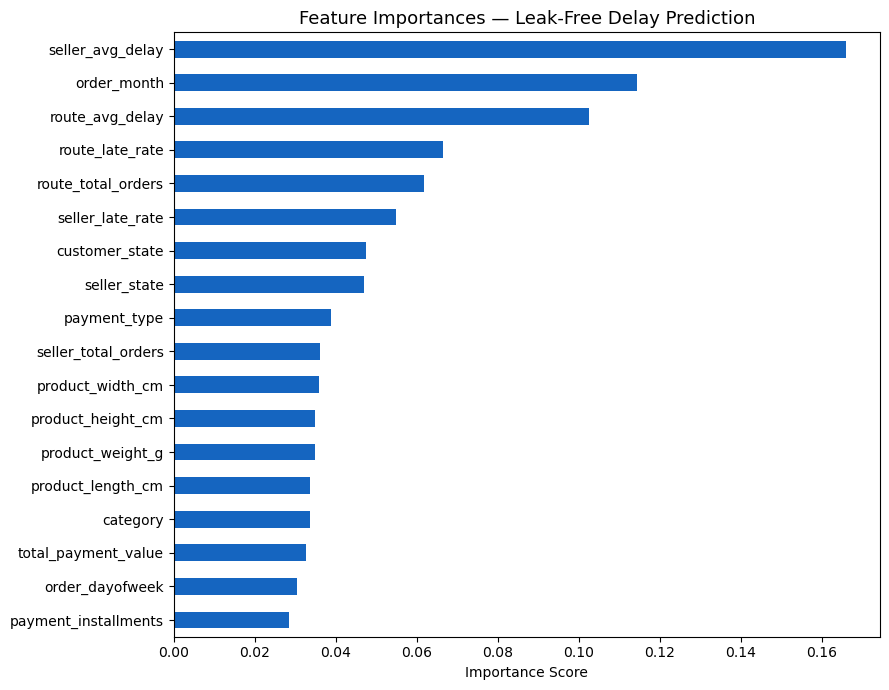

Saved → ../data/feature_importance_leakfree.png ✅


In [50]:
# Cell 12 — Feature importance plot
importances = pd.Series(xgb_reg.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 7))
importances.plot(kind="barh", color="#1565C0")
plt.title("Feature Importances — Leak-Free Delay Prediction", fontsize=13)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../data/feature_importance_leakfree.png", dpi=150)
plt.show()
print("Saved → ../data/feature_importance_leakfree.png ✅")

In [51]:
# Cell 13 — Save predictions to BigQuery
predictions_df = X_test.copy()
predictions_df["actual_delay_days"]    = y_te_reg.values
predictions_df["predicted_delay_days"] = y_pred_reg.round(2)
predictions_df["prediction_error"]     = (y_pred_reg - y_te_reg.values).round(2)
predictions_df["late_probability"]     = y_prob.round(4)
predictions_df["predicted_is_late"]    = y_pred_clf

save_to_bq(predictions_df, "model_predictions")
predictions_df.to_csv("../data/model_predictions.csv", index=False)
print(f"Predictions saved: {predictions_df.shape} ✅")

  ✅ BigQuery: olist.model_predictions
Predictions saved: (22038, 23) ✅


In [52]:
# Cell 14 — Summary
print("=" * 55)
print("03_ml_models.ipynb — COMPLETE")
print("=" * 55)
print(f"\nLeak-Free Model Results:")
print(f"  RMSE    : {rmse:.2f} days")
print(f"  MAE     : {mae:.2f} days")
print(f"  R²      : {r2:.4f}")
print(f"  ROC-AUC : {auc:.4f}")
print(f"\nNote: ROC-AUC is lower than the original 0.97 model")
print(f"because shipping_duration_days (leakage feature) was removed.")
print(f"This score reflects true pre-delivery prediction ability.")
print(f"\nBigQuery tables created:")
print(f"  {DATASET_ID}.seller_stats")
print(f"  {DATASET_ID}.route_stats")
print(f"  {DATASET_ID}.model_predictions")
print(f"\nFiles saved:")
print(f"  ../data/feature_importance_leakfree.png")
print(f"  ../data/model_predictions.csv")
print(f"\nNext → run 04_risk_intelligence.ipynb")

03_ml_models.ipynb — COMPLETE

Leak-Free Model Results:
  RMSE    : 8.56 days
  MAE     : 5.80 days
  R²      : 0.2398
  ROC-AUC : 0.8075

Note: ROC-AUC is lower than the original 0.97 model
because shipping_duration_days (leakage feature) was removed.
This score reflects true pre-delivery prediction ability.

BigQuery tables created:
  olist.seller_stats
  olist.route_stats
  olist.model_predictions

Files saved:
  ../data/feature_importance_leakfree.png
  ../data/model_predictions.csv

Next → run 04_risk_intelligence.ipynb
